In [9]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

Let $(S_n)_{n\in\mathbb{N}}$ be i.i.d. random variables, where $S_n$ gives us the wait time between the $(n-1)$-th and $n$-th calving event. 
Then let us define $J_n = \sum_{k=1}^n S_k$, which represents our jump times. 
Next we use this to define the continuous "jump" process $X_t = \sum_{n=1}^\infty \mathbb{I}_{\{J_n\leq t\}}$ which tells us the number of jumps that have occurred up to the time point t.<br>

Let $(C_n)_{n\in\mathbb{N}}$ be i.i.d geometrically distributed random variables with parameter $q$, where $C_n$ gives us the size of the $n$-th calving event.
This allows us to define the reward process $(W_n)_{n\in\mathbb{N}}$ by $W_n = a\ln(b S_n +1) - C_n$. <br>
Now we can finally define the development of our terminus (the renewal-reward process)
$\begin{equation}Y_t = \sum_{k=1}^{X_t} W_k\;.\end{equation}$

The calving size is given by the following function
$\begin{equation} C_n = a\ln(b S_n+1) +Y_{n-1} - Y_{n}\;.\end{equation}$

In [ ]:
def calving_size(time, new_terminus, initial_terminus, a=1, b=1):
    return a*np.log(b*time + 1) + initial_terminus - new_terminus

In [150]:
initial_terminus = 0
mean = 20
variance = 2
distribution_param = 5

In [151]:
# time_samples = np.random.geometric(.01, 5000)
# position_samples = np.random.normal(mean, variance, 5000)
# calving_samples = np.random.geometric(.24, 5000)

In [152]:
# calving_size_list = []
# for time, position in zip(time_samples, position_samples):
#     calving_size_list += [calving_size(time, position, initial_terminus)]

In [153]:
# plt.scatter(range(1, 5001), calving_size_list)

In [ ]:
def terminus_position_log_growth(time, calve_size, previous_terminus, a=1, b=1):
    return a* np.log(b*time +1)+previous_terminus-calve_size

In [ ]:
def calving_test_runs():
    """
    Here we have geometrically distributed wait times and geometrically distributed calving sizes.
    """
    fig, ax = plt.subplots()
    for k in range(30):
        time_samples = np.random.geometric(.0001, 500)
        calving_samples = np.random.geometric(.115, 500)

        terminus_position_list = [initial_terminus]
        for (time, calve) in zip(time_samples, calving_samples):
            terminus_position_list += [terminus_position_log_growth(time, calve, terminus_position_list[-1])]

        calving_timing = np.insert(time_samples.cumsum(), 0, 0)

        ax.plot(calving_timing, terminus_position_list)

In [292]:
(1-.0001)**100000*.0001

4.537723395901116e-09

In [293]:
1/.0001

10000.0

In [182]:
1/.115

8.695652173913043

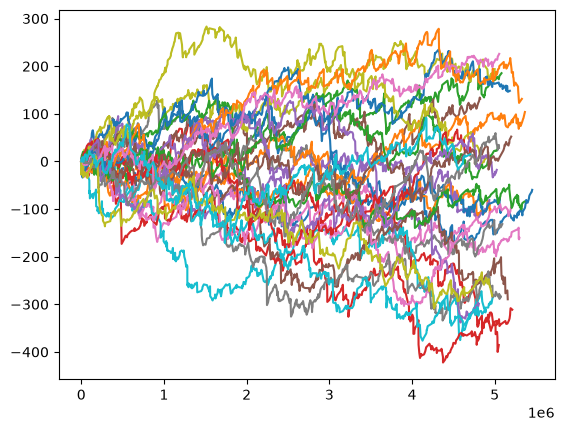

In [180]:
calving_test_runs()

In [ ]:
# this result is quite bad
def memoryless_calving():
    fig, ax = plt.subplots()
    for k in range(30):
        time_samples = np.random.geometric(.00000001, 500)
        calving_samples = np.random.geometric(.8, 500)

        terminus_position_list = []

        calving_timing = np.insert(time_samples.cumsum(), 0, 0)
        cumulative_calving = np.insert(calving_samples.cumsum(), 0, initial_terminus)

        for (time, calve) in zip(calving_timing, cumulative_calving):
            terminus_position_list += [terminus_position_log_growth(time, calve, initial_terminus, 18, 18)]

        ax.plot(calving_timing, terminus_position_list)

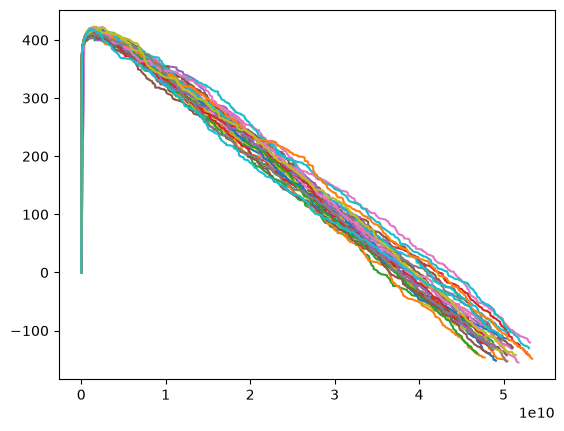

In [257]:
memoryless_calving()

In [ ]:
def terminus_position_linear_growth(time, calve_size, previous_terminus, a=1):
    return a*time +previous_terminus-calve_size

In [281]:
def linear_glacier_growth():
    fig, ax = plt.subplots()
    for k in range(30):
        time_samples = np.random.geometric(.1, 500)
        calving_samples = np.random.geometric(.1, 500)

        terminus_position_list = []

        calving_timing = np.insert(time_samples.cumsum(), 0, 0)
        cumulative_calving = np.insert(calving_samples.cumsum(), 0, initial_terminus)

        for (time, calve) in zip(calving_timing, cumulative_calving):
            terminus_position_list += [terminus_position_linear_growth(time, calve, initial_terminus, 1)]

        ax.plot(calving_timing, terminus_position_list)

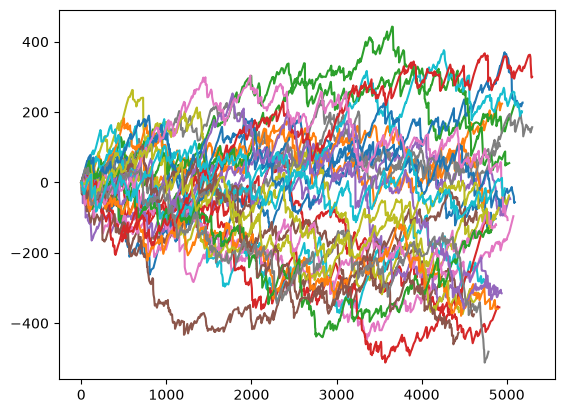

In [282]:
linear_glacier_growth()

In [ ]:
# terminus_position_list = [initial_terminus]
# for (time, calve) in zip(time_samples, calving_samples):
#     terminus_position_list += [terminus_position(time, calve, terminus_position_list[-1])]

# calving_timing = np.insert(time_samples.cumsum(), 0, 0)

In [161]:
print(calving_timing)


[     0     17     94 ... 485525 485569 485658]


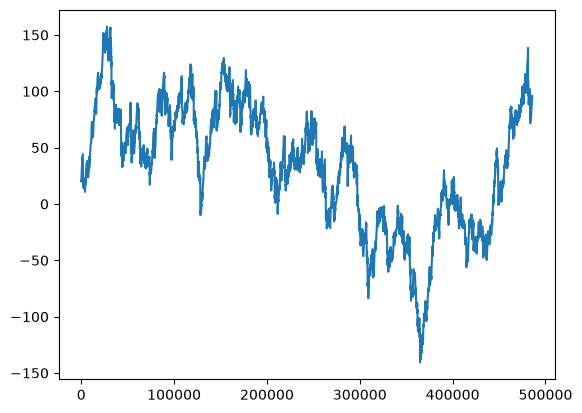

In [162]:
plt.plot(calving_timing, terminus_position_list);